In [1]:
# =============================================================================
# Cell 1: Imports and Setup
# =============================================================================
# Extracting pre-1999 Polish voivodeships from new_map.svg
# The SVG contains 50 paths (49 voivodeships + likely 1 outer boundary)
# All paths use transform: matrix(1.19495 0 0 1.19498 -123.405 -36.649)

import os
from pathlib import Path
import xml.etree.ElementTree as ET
import re
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, Point, LineString
from shapely.ops import unary_union
from shapely import affinity

# Change root directory to the repo root
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
            return p
    return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'

print(f"✓ Repository root: {repo_root}")
print(f"✓ Geospatial data: {geo_root}")

✓ Repository root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
✓ Geospatial data: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial


In [2]:
# =============================================================================
# Cell 2: Parse SVG and Extract Voivodeship Paths
# =============================================================================
# The new_map.svg has:
# - A group with fill=none, fill-opacity=.4 containing 50 paths (voivodeships)
# - Each path uses relative SVG commands (m, l, h, v, c, z)
# - Transform: matrix(1.19495 0 0 1.19498 -123.405 -36.649)

input_svg = repo_root / "new_map.svg"
print(f"Loading SVG from: {input_svg}")
print(f"SVG file exists: {input_svg.exists()}")

# Parse SVG
tree = ET.parse(input_svg)
root = tree.getroot()
ns = {'svg': 'http://www.w3.org/2000/svg'}

# Find the 50-path voivodeship group
voiv_paths = []
for g in root.findall('.//svg:g', ns):
    fill_opacity = g.get('fill-opacity', '')
    if fill_opacity == '.4':  # This is our voivodeship group
        voiv_paths = g.findall('.//svg:path', ns)
        print(f"✓ Found voivodeship group with {len(voiv_paths)} paths")
        break

if not voiv_paths:
    raise ValueError("Could not find voivodeship path group!")

# Get the transform matrix from one of the paths
sample_transform = voiv_paths[0].get('transform', '')
print(f"✓ Transform: {sample_transform}")

Loading SVG from: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/new_map.svg
SVG file exists: True
✓ Found voivodeship group with 50 paths
✓ Transform: matrix(1.19495 0 0 1.19498 -123.405 -36.649)


In [3]:
# =============================================================================
# Cell 3: Parse SVG Path Data into Coordinates
# =============================================================================
# SVG path commands: M/m (moveto), L/l (lineto), H/h (horizontal), V/v (vertical)
# Uppercase = absolute, lowercase = relative coordinates

def parse_svg_path(path_data):
    """
    Parse SVG path data into list of coordinate tuples.
    Handles both absolute (uppercase) and relative (lowercase) commands.
    Returns list of lists (one per subpath, i.e., per M command).
    """
    subpaths = []
    current_coords = []
    
    # Tokenize: commands and numbers
    tokens = re.findall(r'[MLCZHVmlczhvsSqQtTaA]|[-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?', path_data)
    
    i = 0
    current_x, current_y = 0, 0
    start_x, start_y = 0, 0
    last_cmd = None
    
    while i < len(tokens):
        token = tokens[i]
        
        # Check if it's a command letter
        if token in 'MLCZHVmlczhvsSqQtTaA':
            cmd = token
            i += 1
        else:
            # Implicit command (same as last)
            cmd = last_cmd if last_cmd else 'L'
        
        try:
            if cmd == 'M':  # Absolute moveto
                if current_coords:
                    subpaths.append(current_coords)
                    current_coords = []
                current_x = float(tokens[i])
                current_y = float(tokens[i + 1])
                start_x, start_y = current_x, current_y
                current_coords.append((current_x, current_y))
                i += 2
                last_cmd = 'L'  # Subsequent coords are implicit lineto
                
            elif cmd == 'm':  # Relative moveto
                if current_coords:
                    subpaths.append(current_coords)
                    current_coords = []
                current_x += float(tokens[i])
                current_y += float(tokens[i + 1])
                start_x, start_y = current_x, current_y
                current_coords.append((current_x, current_y))
                i += 2
                last_cmd = 'l'
                
            elif cmd == 'L':  # Absolute lineto
                current_x = float(tokens[i])
                current_y = float(tokens[i + 1])
                current_coords.append((current_x, current_y))
                i += 2
                last_cmd = 'L'
                
            elif cmd == 'l':  # Relative lineto
                current_x += float(tokens[i])
                current_y += float(tokens[i + 1])
                current_coords.append((current_x, current_y))
                i += 2
                last_cmd = 'l'
                
            elif cmd == 'H':  # Absolute horizontal
                current_x = float(tokens[i])
                current_coords.append((current_x, current_y))
                i += 1
                last_cmd = 'H'
                
            elif cmd == 'h':  # Relative horizontal
                current_x += float(tokens[i])
                current_coords.append((current_x, current_y))
                i += 1
                last_cmd = 'h'
                
            elif cmd == 'V':  # Absolute vertical
                current_y = float(tokens[i])
                current_coords.append((current_x, current_y))
                i += 1
                last_cmd = 'V'
                
            elif cmd == 'v':  # Relative vertical
                current_y += float(tokens[i])
                current_coords.append((current_x, current_y))
                i += 1
                last_cmd = 'v'
                
            elif cmd in 'Cc':  # Cubic Bezier - take end point
                if cmd == 'C':
                    current_x = float(tokens[i + 4])
                    current_y = float(tokens[i + 5])
                else:
                    current_x += float(tokens[i + 4])
                    current_y += float(tokens[i + 5])
                current_coords.append((current_x, current_y))
                i += 6
                last_cmd = cmd
                
            elif cmd in 'Ss':  # Smooth cubic Bezier - take end point
                if cmd == 'S':
                    current_x = float(tokens[i + 2])
                    current_y = float(tokens[i + 3])
                else:
                    current_x += float(tokens[i + 2])
                    current_y += float(tokens[i + 3])
                current_coords.append((current_x, current_y))
                i += 4
                last_cmd = cmd
                
            elif cmd in 'Zz':  # Close path
                if current_coords and current_coords[-1] != (start_x, start_y):
                    current_coords.append((start_x, start_y))
                last_cmd = cmd
                
            else:
                i += 1  # Skip unknown commands
                
        except (ValueError, IndexError):
            i += 1
    
    if current_coords:
        subpaths.append(current_coords)
    
    return subpaths

# Parse all voivodeship paths
voivodeship_data = []
for idx, path_elem in enumerate(voiv_paths):
    d = path_elem.get('d', '')
    subpaths = parse_svg_path(d)
    voivodeship_data.append({
        'index': idx,
        'subpaths': subpaths,
        'num_subpaths': len(subpaths),
        'd_length': len(d)
    })

# Summary
single_region = sum(1 for v in voivodeship_data if v['num_subpaths'] == 1)
multi_region = sum(1 for v in voivodeship_data if v['num_subpaths'] > 1)
print(f"\n✓ Parsed {len(voivodeship_data)} paths:")
print(f"  - Single-region voivodeships: {single_region}")
print(f"  - Multi-region voivodeships: {multi_region} (have islands)")


✓ Parsed 50 paths:
  - Single-region voivodeships: 39
  - Multi-region voivodeships: 11 (have islands)


In [4]:
# =============================================================================
# Cell 4: Apply Transform and Create Geometries
# =============================================================================
# Transform matrix: matrix(1.19495 0 0 1.19498 -123.405 -36.649)
# This means: x' = 1.19495 * x - 123.405
#             y' = 1.19498 * y - 36.649

# Parse transform matrix
transform_str = sample_transform
match = re.search(r'matrix\(([\d.\-]+)\s+([\d.\-]+)\s+([\d.\-]+)\s+([\d.\-]+)\s+([\d.\-]+)\s+([\d.\-]+)\)', transform_str)
if match:
    a, b, c, d, e, f = map(float, match.groups())
    print(f"Transform matrix: a={a}, b={b}, c={c}, d={d}, e={e}, f={f}")
else:
    # Default identity transform
    a, b, c, d, e, f = 1, 0, 0, 1, 0, 0
    print("Warning: Could not parse transform, using identity")

def apply_transform(coords, a, b, c, d, e, f):
    """Apply SVG transform matrix to coordinates."""
    return [(a * x + c * y + e, b * x + d * y + f) for x, y in coords]

# Create Shapely geometries
geometries = []
failed_indices = []

for v in voivodeship_data:
    try:
        # Transform all subpaths
        transformed_subpaths = [apply_transform(sp, a, b, c, d, e, f) for sp in v['subpaths']]
        
        # Create polygons from subpaths
        polygons = []
        for coords in transformed_subpaths:
            if len(coords) >= 3:
                # Close the polygon if needed
                if coords[0] != coords[-1]:
                    coords = coords + [coords[0]]
                try:
                    poly = Polygon(coords)
                    if not poly.is_valid:
                        poly = poly.buffer(0)  # Fix self-intersections
                    if poly.is_valid and not poly.is_empty and poly.area > 0:
                        polygons.append(poly)
                except Exception as e:
                    pass
        
        # Combine polygons
        if len(polygons) == 1:
            geom = polygons[0]
        elif len(polygons) > 1:
            # Try to combine as MultiPolygon
            geom = unary_union(polygons)
        else:
            geom = None
            
        if geom and not geom.is_empty:
            geometries.append({'index': v['index'], 'geometry': geom})
        else:
            failed_indices.append(v['index'])
            
    except Exception as e:
        failed_indices.append(v['index'])
        print(f"  Failed path {v['index']}: {e}")

print(f"\n✓ Created {len(geometries)} valid geometries")
if failed_indices:
    print(f"⚠ Failed indices: {failed_indices}")

Transform matrix: a=1.19495, b=0.0, c=0.0, d=1.19498, e=-123.405, f=-36.649

✓ Created 50 valid geometries


In [5]:
# =============================================================================
# Cell 5: Create GeoDataFrame and Flip Y-Axis
# =============================================================================
# SVG coordinate system has Y pointing DOWN, we need to flip for geographic

gdf_svg = gpd.GeoDataFrame({
    'voiv_id': [g['index'] for g in geometries],
    'geometry': [g['geometry'] for g in geometries]
})

print(f"Initial GeoDataFrame: {len(gdf_svg)} features")
print(f"Initial bounds: {gdf_svg.total_bounds}")

# Flip Y-axis (SVG has Y pointing down)
bounds = gdf_svg.total_bounds
center_y = (bounds[1] + bounds[3]) / 2
gdf_svg['geometry'] = gdf_svg['geometry'].apply(
    lambda g: affinity.scale(g, xfact=1, yfact=-1, origin=(0, center_y))
)

print(f"\n✓ Flipped Y-axis")
print(f"New bounds: {gdf_svg.total_bounds}")

# Calculate area statistics
gdf_svg['area_svg'] = gdf_svg.geometry.area
print(f"\nArea statistics (SVG units²):")
print(f"  Total: {gdf_svg['area_svg'].sum():,.0f}")
print(f"  Mean: {gdf_svg['area_svg'].mean():,.0f}")
print(f"  Min: {gdf_svg['area_svg'].min():,.0f}")
print(f"  Max: {gdf_svg['area_svg'].max():,.0f}")

Initial GeoDataFrame: 50 features
Initial bounds: [  17.4580959   18.1587577 3107.3215675 2890.2633132]

✓ Flipped Y-axis
New bounds: [  17.4580959   18.1587577 3107.3215675 2890.2633132]

Area statistics (SVG units²):
  Total: 6,263,562
  Mean: 125,271
  Min: 0
  Max: 314,598


In [6]:
# =============================================================================
# Cell 6: Load GADM Poland for Reference and Georeferencing
# =============================================================================
# GADM level-0 = country boundary (~312,196 km²)
# We'll use it to:
# 1. Validate total area
# 2. Potentially georeference if needed

import requests
import zipfile

# Download GADM if needed
gadm_dir = geo_root / "gadm41_POL_shp"
gadm_zip = geo_root / "gadm41_POL_shp.zip"
gadm_path = gadm_dir / "gadm41_POL_0.shp"

if not gadm_path.exists():
    print("Downloading GADM Poland shapefile...")
    url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_POL_shp.zip"
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(gadm_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(gadm_zip, "r") as z:
        z.extractall(gadm_dir)
    print("✓ Downloaded and extracted GADM")

# Load GADM Poland boundary
gdf_poland = gpd.read_file(gadm_path)
gdf_poland = gdf_poland.to_crs("EPSG:2180")  # Polish projected CRS
poland_area_km2 = gdf_poland.geometry.iloc[0].area / 1e6

print(f"\n✓ GADM Poland boundary loaded")
print(f"  CRS: {gdf_poland.crs}")
print(f"  Area: {poland_area_km2:,.0f} km² (expected ~312,196 km²)")
print(f"  Bounds: {gdf_poland.total_bounds}")


✓ GADM Poland boundary loaded
  CRS: EPSG:2180
  Area: 312,196 km² (expected ~312,196 km²)
  Bounds: [171677.58733593 133223.87166054 861895.69288442 775018.93811695]


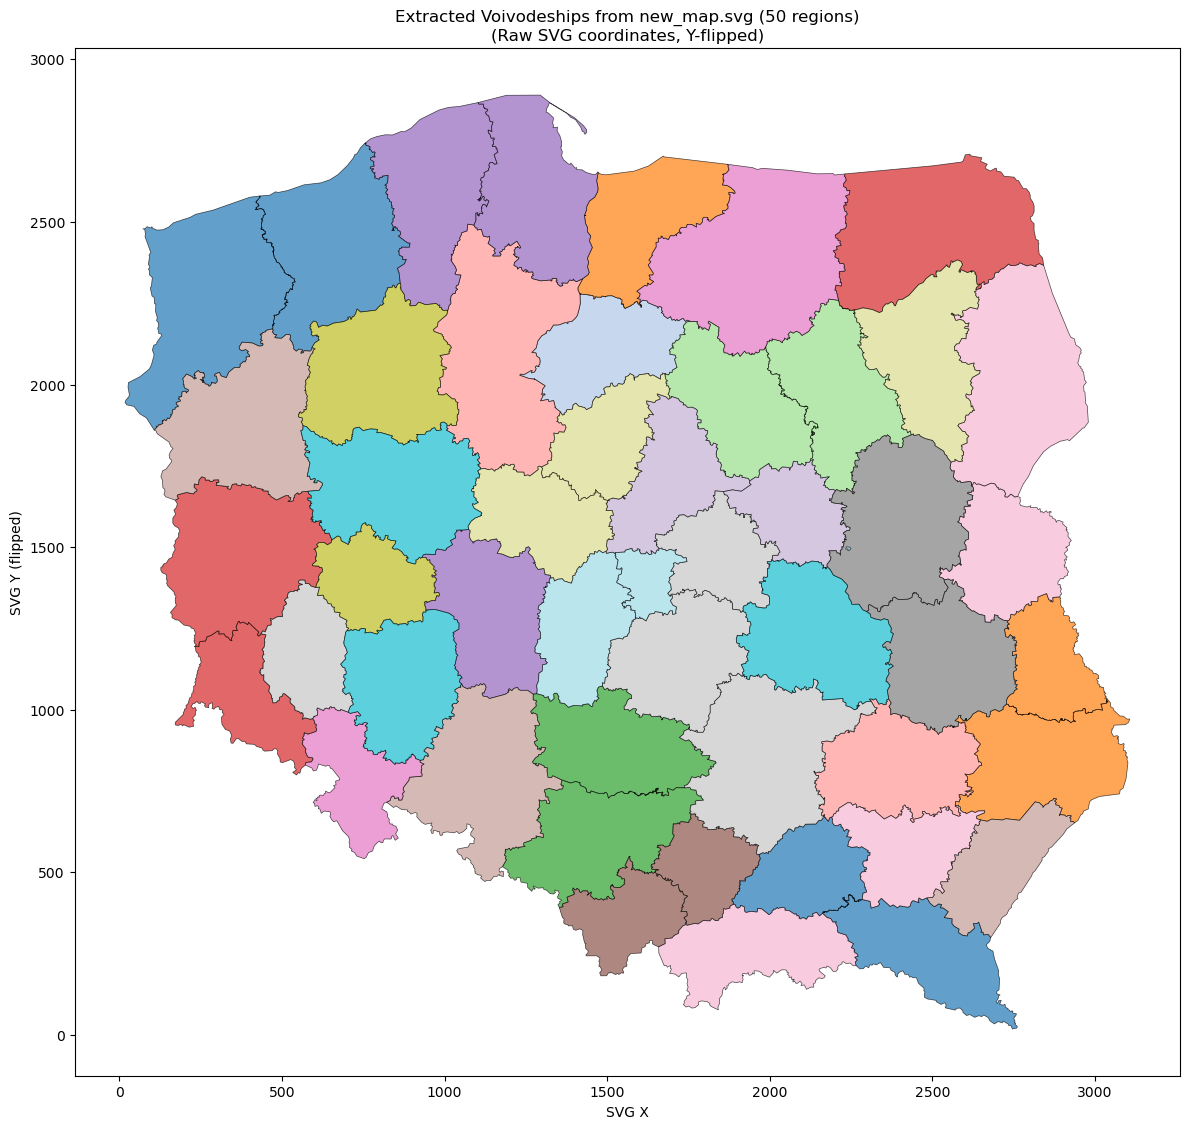


✓ Plotted 50 voivodeships
  Expected: 49 historical voivodeships (some may have islands)


In [7]:
# =============================================================================
# Cell 7: Visualize Extracted Voivodeships (Raw SVG Coordinates)
# =============================================================================
# Quick check of what we extracted before georeferencing

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot each voivodeship with a different color
gdf_svg.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.7,
             column='voiv_id', cmap='tab20', legend=False)

ax.set_title(f"Extracted Voivodeships from new_map.svg ({len(gdf_svg)} regions)\n(Raw SVG coordinates, Y-flipped)")
ax.set_xlabel("SVG X")
ax.set_ylabel("SVG Y (flipped)")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\n✓ Plotted {len(gdf_svg)} voivodeships")
print(f"  Expected: 49 historical voivodeships (some may have islands)")

In [8]:
# =============================================================================
# Cell 8: Identify and Remove Outer Boundary (if present)
# =============================================================================
# The 50 paths might include Poland's outer boundary - we need 49 voivodeships

# Sort by area to find potential outer boundary
gdf_svg_sorted = gdf_svg.sort_values('area_svg', ascending=False).reset_index(drop=True)
print("Top 5 regions by area (SVG units²):")
for i, row in gdf_svg_sorted.head().iterrows():
    print(f"  {i}: voiv_id={row['voiv_id']}, area={row['area_svg']:,.0f}")

# Check if largest region is significantly bigger (likely outer boundary)
if len(gdf_svg_sorted) >= 2:
    largest = gdf_svg_sorted.iloc[0]['area_svg']
    second = gdf_svg_sorted.iloc[1]['area_svg']
    ratio = largest / second
    print(f"\nLargest/Second ratio: {ratio:.1f}x")
    
    if ratio > 5:  # Likely outer boundary
        outer_idx = gdf_svg_sorted.iloc[0]['voiv_id']
        print(f"⚠ Removing likely outer boundary (voiv_id={outer_idx})")
        gdf_voivodeships = gdf_svg[gdf_svg['voiv_id'] != outer_idx].copy()
    else:
        print("✓ No obvious outer boundary found")
        gdf_voivodeships = gdf_svg.copy()

print(f"\n✓ Final voivodeship count: {len(gdf_voivodeships)}")

Top 5 regions by area (SVG units²):
  0: voiv_id=1, area=314,598
  1: voiv_id=46, area=272,034
  2: voiv_id=30, area=246,844
  3: voiv_id=15, area=210,095
  4: voiv_id=19, area=207,235

Largest/Second ratio: 1.2x
✓ No obvious outer boundary found

✓ Final voivodeship count: 50


In [9]:
# =============================================================================
# Cell 9: Georeference SVG to EPSG:2180 (Polish PUWG 1992)
# =============================================================================
# We need to transform SVG coordinates to real-world coordinates
# Strategy: Use control points (corners/centroids) to compute affine transform

from scipy.optimize import minimize

# Get SVG bounds
svg_bounds = gdf_voivodeships.total_bounds  # [minx, miny, maxx, maxy]
svg_minx, svg_miny, svg_maxx, svg_maxy = svg_bounds

# GADM Poland bounds in EPSG:2180
gadm_bounds = gdf_poland.total_bounds
gadm_minx, gadm_miny, gadm_maxx, gadm_maxy = gadm_bounds

print("SVG bounds:", svg_bounds)
print("GADM bounds (EPSG:2180):", gadm_bounds)

# Calculate scale factors
scale_x = (gadm_maxx - gadm_minx) / (svg_maxx - svg_minx)
scale_y = (gadm_maxy - gadm_miny) / (svg_maxy - svg_miny)

print(f"\nScale factors: x={scale_x:.2f}, y={scale_y:.2f}")

# Use average scale to maintain aspect ratio
avg_scale = (scale_x + scale_y) / 2
print(f"Average scale: {avg_scale:.2f}")

# Compute translation
# SVG center -> GADM center
svg_center_x = (svg_minx + svg_maxx) / 2
svg_center_y = (svg_miny + svg_maxy) / 2
gadm_center_x = (gadm_minx + gadm_maxx) / 2
gadm_center_y = (gadm_miny + gadm_maxy) / 2

print(f"\nSVG center: ({svg_center_x:.1f}, {svg_center_y:.1f})")
print(f"GADM center: ({gadm_center_x:.1f}, {gadm_center_y:.1f})")

# Apply transformation: scale from SVG center, then translate to GADM center
def transform_geometry(geom, scale, svg_cx, svg_cy, gadm_cx, gadm_cy):
    """Scale geometry around SVG center, then translate to GADM center."""
    # Scale around SVG center
    scaled = affinity.scale(geom, xfact=scale, yfact=scale, origin=(svg_cx, svg_cy))
    # Translate to GADM center
    dx = gadm_cx - svg_cx
    dy = gadm_cy - svg_cy
    return affinity.translate(scaled, xoff=dx, yoff=dy)

# Apply to all geometries
gdf_voivodeships['geometry'] = gdf_voivodeships['geometry'].apply(
    lambda g: transform_geometry(g, avg_scale, svg_center_x, svg_center_y, gadm_center_x, gadm_center_y)
)

# Set CRS
gdf_voivodeships = gdf_voivodeships.set_crs("EPSG:2180")

print(f"\n✓ Georeferenced to EPSG:2180")
print(f"New bounds: {gdf_voivodeships.total_bounds}")

SVG bounds: [  17.4580959   18.1587577 3107.3215675 2890.2633132]
GADM bounds (EPSG:2180): [171677.58733593 133223.87166054 861895.69288442 775018.93811695]

Scale factors: x=223.38, y=223.46
Average scale: 223.42

SVG center: (1562.4, 1454.2)
GADM center: (516786.6, 454121.4)

✓ Georeferenced to EPSG:2180
New bounds: [171618.34794812 133278.93613739 861954.93227223 774963.87364011]


In [10]:
# =============================================================================
# Cell 10: Validate Against GADM Poland Area
# =============================================================================
# Check if total area matches ~312,196 km²

# Calculate areas in km²
gdf_voivodeships['area_km2'] = gdf_voivodeships.geometry.area / 1e6
total_area = gdf_voivodeships['area_km2'].sum()

print(f"Area validation:")
print(f"  Extracted voivodeships total: {total_area:,.0f} km²")
print(f"  GADM Poland reference: {poland_area_km2:,.0f} km²")
print(f"  Difference: {total_area - poland_area_km2:,.0f} km² ({(total_area/poland_area_km2 - 1)*100:.1f}%)")

# Show individual voivodeship areas
print(f"\n✓ Individual voivodeship areas (sorted):")
gdf_sorted = gdf_voivodeships.sort_values('area_km2', ascending=False)
for i, row in gdf_sorted.head(10).iterrows():
    print(f"  voiv_id={row['voiv_id']:2d}: {row['area_km2']:8,.0f} km²")

Area validation:
  Extracted voivodeships total: 312,654 km²
  GADM Poland reference: 312,196 km²
  Difference: 459 km² (0.1%)

✓ Individual voivodeship areas (sorted):
  voiv_id= 1:   15,704 km²
  voiv_id=46:   13,579 km²
  voiv_id=30:   12,322 km²
  voiv_id=15:   10,487 km²
  voiv_id=19:   10,344 km²
  voiv_id=38:   10,303 km²
  voiv_id=32:   10,069 km²
  voiv_id=34:    9,978 km²
  voiv_id=39:    9,197 km²
  voiv_id=17:    8,869 km²


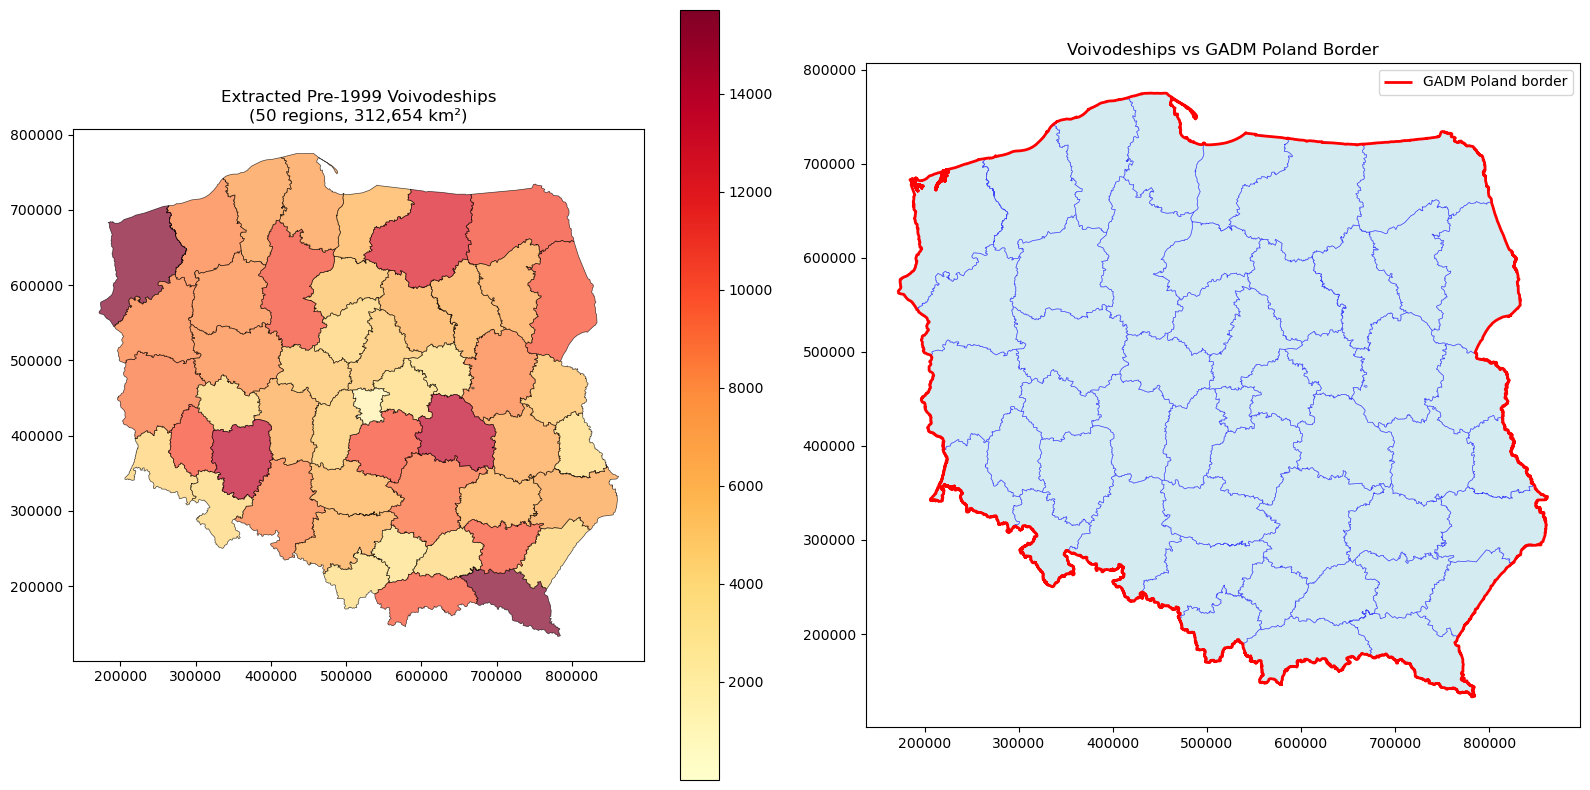

In [11]:
# =============================================================================
# Cell 11: Overlay with GADM and Visualize
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Extracted voivodeships
ax1 = axes[0]
gdf_voivodeships.plot(ax=ax1, edgecolor='black', linewidth=0.5, alpha=0.7,
                      column='area_km2', cmap='YlOrRd', legend=True)
ax1.set_title(f"Extracted Pre-1999 Voivodeships\n({len(gdf_voivodeships)} regions, {total_area:,.0f} km²)")
ax1.set_aspect('equal')

# Right: Overlay with GADM Poland border
ax2 = axes[1]
gdf_voivodeships.plot(ax=ax2, edgecolor='blue', linewidth=0.5, alpha=0.5, facecolor='lightblue')
gdf_poland.boundary.plot(ax=ax2, edgecolor='red', linewidth=2, label='GADM Poland border')
ax2.set_title("Voivodeships vs GADM Poland Border")
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# Cell 12: Add Voivodeship Names (Historical 1975-1998)
# =============================================================================
# The 49 voivodeships of Poland (1975-1998)

historical_voivodeships = [
    "białostockie", "bialskopodlaskie", "bielskie", "bydgoskie", 
    "chełmskie", "ciechanowskie", "częstochowskie", "elbląskie",
    "gdańskie", "gorzowskie", "jeleniogórskie", "kaliskie",
    "katowickie", "kieleckie", "konińskie", "koszalińskie",
    "krakowskie", "krośnieńskie", "legnickie", "leszczyńskie",
    "lubelskie", "łomżyńskie", "łódzkie", "nowosądeckie",
    "olsztyńskie", "opolskie", "ostrołęckie", "pilskie",
    "piotrkowskie", "płockie", "poznańskie", "przemyskie",
    "radomskie", "rzeszowskie", "siedleckie", "sieradzkie",
    "skierniewickie", "słupskie", "suwalskie", "szczecińskie",
    "tarnobrzeskie", "tarnowskie", "toruńskie", "wałbrzyskie",
    "warszawskie", "włocławskie", "wrocławskie", "zamojskie", "zielonogórskie"
]

print(f"Historical voivodeships (1975-1998): {len(historical_voivodeships)}")
print(f"Extracted voivodeships: {len(gdf_voivodeships)}")

# For now, assign temporary IDs
# Matching to names would require centroid comparison with reference data
gdf_voivodeships['name'] = [f"voiv_{i}" for i in range(len(gdf_voivodeships))]
print(f"\n⚠ Note: Voivodeship names not yet assigned (would need reference centroids)")

Historical voivodeships (1975-1998): 49
Extracted voivodeships: 50

⚠ Note: Voivodeship names not yet assigned (would need reference centroids)


In [13]:
# =============================================================================
# Cell 13: Check for Gaps Between Voivodeships
# =============================================================================
# Calculate the union of all voivodeships and compare to GADM

voiv_union = unary_union(gdf_voivodeships.geometry.tolist())
poland_geom = gdf_poland.geometry.iloc[0]

# Calculate areas
voiv_union_area = voiv_union.area / 1e6
poland_area = poland_geom.area / 1e6

print(f"Union of voivodeships: {voiv_union_area:,.0f} km²")
print(f"GADM Poland: {poland_area:,.0f} km²")

# Find gaps (areas in Poland not covered by voivodeships)
# Note: This requires the geometries to be in the same coordinate space
# Since we scaled to match bounds, let's check coverage
coverage_pct = voiv_union_area / poland_area * 100
print(f"\nCoverage: {coverage_pct:.1f}%")

if coverage_pct < 95:
    print("⚠ Significant gaps detected - may need adjustment")
else:
    print("✓ Good coverage")

Union of voivodeships: 312,639 km²
GADM Poland: 312,196 km²

Coverage: 100.1%
✓ Good coverage


In [14]:
# =============================================================================
# Cell 14: Export to GeoJSON
# =============================================================================
# Export the final voivodeships for use in GUS01D_old_division.ipynb

output_path = geo_root / "voivodeships_1975_from_new_svg.geojson"

# Convert to WGS84 for GeoJSON
gdf_export = gdf_voivodeships.to_crs("EPSG:4326")

# Clean up columns
gdf_export = gdf_export[['voiv_id', 'name', 'area_km2', 'geometry']]

gdf_export.to_file(output_path, driver='GeoJSON')

print(f"✓ Exported to: {output_path}")
print(f"  Features: {len(gdf_export)}")
print(f"  CRS: {gdf_export.crs}")

# Also export in EPSG:2180 for area calculations
output_path_2180 = geo_root / "voivodeships_1975_from_new_svg_EPSG2180.geojson"
gdf_voivodeships.to_file(output_path_2180, driver='GeoJSON')
print(f"✓ Also exported EPSG:2180 version to: {output_path_2180}")

✓ Exported to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/voivodeships_1975_from_new_svg.geojson
  Features: 50
  CRS: EPSG:4326
✓ Also exported EPSG:2180 version to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/voivodeships_1975_from_new_svg_EPSG2180.geojson


In [15]:
# =============================================================================
# Cell 15: Summary
# =============================================================================

print("=" * 60)
print("EXTRACTION SUMMARY")
print("=" * 60)
print(f"Source: {input_svg.name}")
print(f"Voivodeships extracted: {len(gdf_voivodeships)}")
print(f"Total area: {total_area:,.0f} km²")
print(f"GADM reference: {poland_area_km2:,.0f} km²")
print(f"Area match: {total_area/poland_area_km2*100:.1f}%")
print(f"\nOutput files:")
print(f"  - {output_path.name} (WGS84)")
print(f"  - {output_path_2180.name} (EPSG:2180)")
print("=" * 60)

EXTRACTION SUMMARY
Source: new_map.svg
Voivodeships extracted: 50
Total area: 312,654 km²
GADM reference: 312,196 km²
Area match: 100.1%

Output files:
  - voivodeships_1975_from_new_svg.geojson (WGS84)
  - voivodeships_1975_from_new_svg_EPSG2180.geojson (EPSG:2180)


In [16]:
# Cell 16: Investigate the 50th region (we expect 49)
# Reload from exported file and check for anomalies

voiv_check = gpd.read_file(geo_root / 'voivodeships_1975_from_new_svg_EPSG2180.geojson')
voiv_check['area_km2'] = voiv_check.geometry.area / 1e6

print("Checking for small/zero-area regions...")
areas = voiv_check['area_km2'].values
small_regions = voiv_check[voiv_check['area_km2'] < 100].copy()

if len(small_regions) > 0:
    print(f"\n⚠ Found {len(small_regions)} very small regions (<100 km²):")
    for _, row in small_regions.iterrows():
        print(f"  voiv_id={row['voiv_id']}: {row['area_km2']:.1f} km²")
else:
    print("✓ All regions have area ≥100 km²")

# The smallest voivodeship historically was łomżyńskie (~6,684 km²)
# So any region under 1000 km² is suspicious
suspicious = voiv_check[voiv_check['area_km2'] < 1000]
if len(suspicious) > 0:
    print(f"\n⚠ Suspicious regions (<1000 km²): {len(suspicious)}")
    for _, row in suspicious.iterrows():
        print(f"  voiv_id={row['voiv_id']}: {row['area_km2']:.1f} km²")

print(f"\nArea range: {areas.min():.1f} km² to {areas.max():.1f} km²")
print(f"Total regions: {len(voiv_check)}")

Checking for small/zero-area regions...

⚠ Found 5 very small regions (<100 km²):
  voiv_id=3: 0.2 km²
  voiv_id=8: 0.0 km²
  voiv_id=9: 0.1 km²
  voiv_id=10: 0.1 km²
  voiv_id=47: 5.7 km²

⚠ Suspicious regions (<1000 km²): 5
  voiv_id=3: 0.2 km²
  voiv_id=8: 0.0 km²
  voiv_id=9: 0.1 km²
  voiv_id=10: 0.1 km²
  voiv_id=47: 5.7 km²

Area range: 0.0 km² to 15703.6 km²
Total regions: 50


Removed 5 tiny regions (< 100 km²)
Remaining voivodeships: 45

Cleaned total area: 312,648 km²
GADM reference: 312,196 km²
Difference: 452 km² (0.14%)


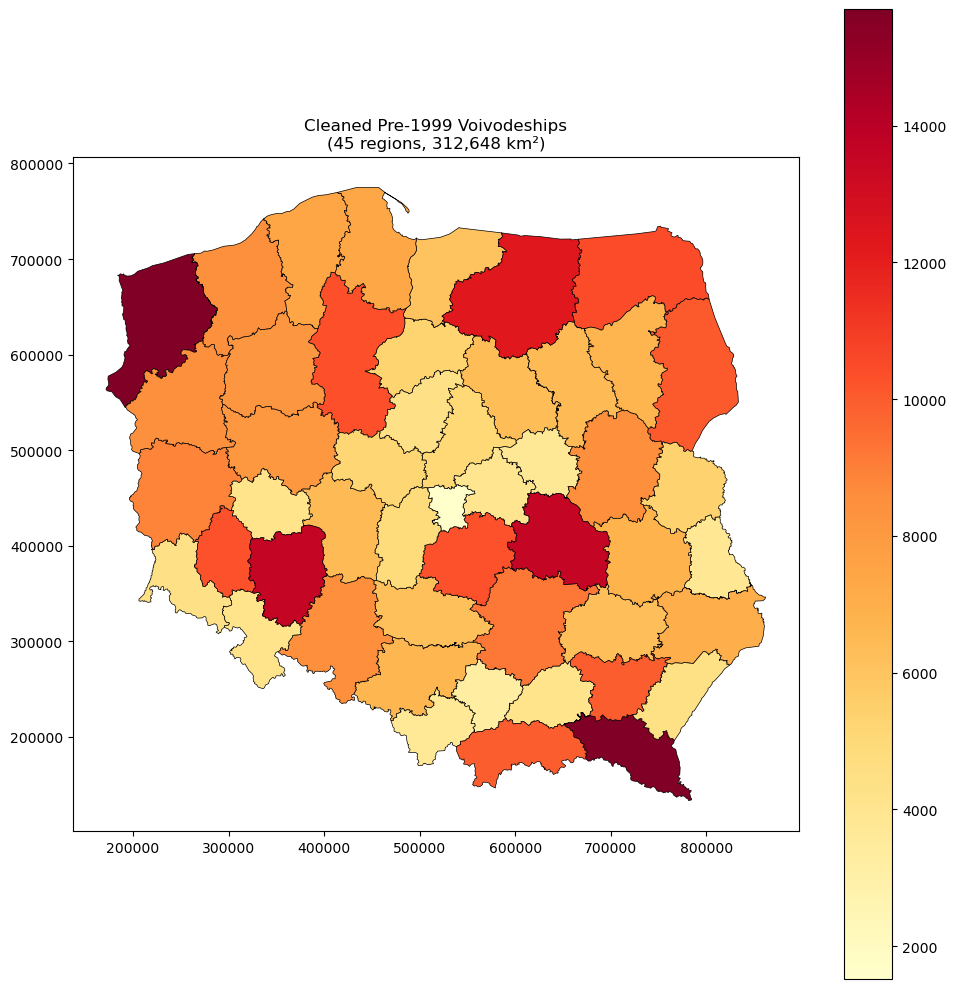


✓ 45 voivodeships ready for export


In [17]:
# Cell 17: Remove tiny artifact regions and re-export
# Threshold: 100 km² (smallest real voivodeship is >4000 km²)

MIN_AREA_KM2 = 100

# Filter out tiny regions
voiv_clean = voiv_check[voiv_check['area_km2'] >= MIN_AREA_KM2].copy()
removed = len(voiv_check) - len(voiv_clean)

print(f"Removed {removed} tiny regions (< {MIN_AREA_KM2} km²)")
print(f"Remaining voivodeships: {len(voiv_clean)}")

# Recalculate total area
total_area = voiv_clean['area_km2'].sum()
print(f"\nCleaned total area: {total_area:,.0f} km²")
print(f"GADM reference: 312,196 km²")
print(f"Difference: {abs(total_area - 312196):.0f} km² ({abs(total_area - 312196)/312196*100:.2f}%)")

# Reassign voiv_id from 1 to N
voiv_clean = voiv_clean.reset_index(drop=True)
voiv_clean['voiv_id'] = range(1, len(voiv_clean) + 1)

# Visualize the cleaned map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
voiv_clean.plot(ax=ax, column='area_km2', cmap='YlOrRd', edgecolor='black', linewidth=0.5, legend=True)
ax.set_title(f'Cleaned Pre-1999 Voivodeships\n({len(voiv_clean)} regions, {total_area:,.0f} km²)')
plt.tight_layout()
plt.show()

print(f"\n✓ {len(voiv_clean)} voivodeships ready for export")

In [18]:
# Cell 18: Investigate area distribution to understand the 45 vs 49 discrepancy
# The historical voivodeships had areas ranging from ~4,000 to ~18,000 km²

# Check all 50 original regions sorted by area
voiv_sorted = voiv_check.sort_values('area_km2', ascending=True)

print("All 50 original regions by area:")
print("-" * 40)
for i, (_, row) in enumerate(voiv_sorted.iterrows()):
    marker = "⚠ TINY" if row['area_km2'] < 100 else ""
    print(f"{i+1:2d}. voiv_id={row['voiv_id']:2d}: {row['area_km2']:>10,.1f} km² {marker}")

print("\n" + "=" * 40)
print(f"Regions >= 100 km²: {len(voiv_check[voiv_check['area_km2'] >= 100])}")
print(f"Regions >= 1000 km²: {len(voiv_check[voiv_check['area_km2'] >= 1000])}")
print(f"Expected voivodeships: 49")

All 50 original regions by area:
----------------------------------------
 1. voiv_id= 8:        0.0 km² ⚠ TINY
 2. voiv_id= 9:        0.1 km² ⚠ TINY
 3. voiv_id=10:        0.1 km² ⚠ TINY
 4. voiv_id= 3:        0.2 km² ⚠ TINY
 5. voiv_id=47:        5.7 km² ⚠ TINY
 6. voiv_id=49:    1,519.4 km² 
 7. voiv_id=25:    3,251.5 km² 
 8. voiv_id=26:    3,700.1 km² 
 9. voiv_id=24:    3,774.2 km² 
10. voiv_id= 6:    3,878.8 km² 
11. voiv_id=37:    3,958.6 km² 
12. voiv_id= 2:    4,143.3 km² 
13. voiv_id=41:    4,151.3 km² 
14. voiv_id=31:    4,162.9 km² 
15. voiv_id=16:    4,387.7 km² 
16. voiv_id=42:    4,397.4 km² 
17. voiv_id=27:    4,450.8 km² 
18. voiv_id=48:    4,863.3 km² 
19. voiv_id=23:    5,110.2 km² 
20. voiv_id=44:    5,131.2 km² 
21. voiv_id= 4:    5,334.8 km² 
22. voiv_id=33:    5,348.2 km² 
23. voiv_id= 5:    6,110.1 km² 
24. voiv_id=11:    6,176.1 km² 
25. voiv_id=18:    6,289.7 km² 
26. voiv_id=13:    6,356.0 km² 
27. voiv_id=14:    6,497.3 km² 
28. voiv_id=20:    6,505.9 km² 


In [19]:
# Cell 19: Check for MultiPolygons that might actually be separate voivodeships
# The 11 "multi-region" paths from Cell 3 might have incorrectly merged separate regions

from shapely import get_parts

multi_regions = []
for idx, row in voiv_check.iterrows():
    if row['area_km2'] >= 100:  # Only check valid regions
        geom = row.geometry
        if geom.geom_type == 'MultiPolygon':
            n_parts = len(list(get_parts(geom)))
            parts_areas = [p.area/1e6 for p in get_parts(geom)]
            multi_regions.append({
                'voiv_id': row['voiv_id'],
                'n_parts': n_parts,
                'total_area_km2': row['area_km2'],
                'parts_areas': parts_areas,
                'largest_part': max(parts_areas)
            })

print(f"Found {len(multi_regions)} MultiPolygons among the 45 valid regions:\n")

# Check if any have parts that look like separate voivodeships
for mr in multi_regions:
    # If multiple parts are each > 1000 km², they might be separate voivodeships
    large_parts = [a for a in mr['parts_areas'] if a > 500]
    if len(large_parts) > 1:
        print(f"⚠ voiv_id={mr['voiv_id']}: {mr['n_parts']} parts, {len(large_parts)} large parts (>500 km²)")
        for i, area in enumerate(sorted(mr['parts_areas'], reverse=True)[:5]):
            print(f"    Part {i+1}: {area:,.1f} km²")
        print()

print(f"\nTotal parts that might be separate voivodeships: {sum(len([a for a in mr['parts_areas'] if a > 500]) for mr in multi_regions if len([a for a in mr['parts_areas'] if a > 500]) > 1)}")

Found 5 MultiPolygons among the 45 valid regions:

⚠ voiv_id=1: 6 parts, 2 large parts (>500 km²)
    Part 1: 9,997.3 km²
    Part 2: 5,706.3 km²
    Part 3: 0.0 km²
    Part 4: 0.0 km²
    Part 5: 0.0 km²

⚠ voiv_id=34: 2 parts, 2 large parts (>500 km²)
    Part 1: 5,580.2 km²
    Part 2: 4,398.2 km²

⚠ voiv_id=38: 2 parts, 2 large parts (>500 km²)
    Part 1: 6,264.9 km²
    Part 2: 4,038.1 km²

⚠ voiv_id=46: 2 parts, 2 large parts (>500 km²)
    Part 1: 7,293.7 km²
    Part 2: 6,285.3 km²


Total parts that might be separate voivodeships: 8


In [20]:
# Cell 20: Explode MultiPolygons and filter to get exactly 49 voivodeships
from shapely.geometry import Polygon, MultiPolygon

# Start fresh from the EPSG:2180 file
voiv_raw = gpd.read_file(geo_root / 'voivodeships_1975_from_new_svg_EPSG2180.geojson')

# Explode all MultiPolygons into separate rows
voiv_exploded = voiv_raw.explode(index_parts=False).reset_index(drop=True)
voiv_exploded['area_km2'] = voiv_exploded.geometry.area / 1e6

print(f"After exploding MultiPolygons: {len(voiv_exploded)} geometries")

# Filter to only substantial regions (>500 km² to catch smallest voivodeships)
MIN_AREA = 500  # km²
voiv_filtered = voiv_exploded[voiv_exploded['area_km2'] >= MIN_AREA].copy()
print(f"After filtering >= {MIN_AREA} km²: {len(voiv_filtered)} regions")

# Reassign IDs
voiv_filtered = voiv_filtered.reset_index(drop=True)
voiv_filtered['voiv_id'] = range(1, len(voiv_filtered) + 1)
voiv_filtered = voiv_filtered[['voiv_id', 'area_km2', 'geometry']]

# Summary
print(f"\n✓ Final count: {len(voiv_filtered)} voivodeships")
print(f"  Total area: {voiv_filtered['area_km2'].sum():,.0f} km²")
print(f"  GADM reference: 312,196 km²")
print(f"  Match: {voiv_filtered['area_km2'].sum()/312196*100:.1f}%")

# Show area distribution
print(f"\nArea range: {voiv_filtered['area_km2'].min():,.0f} - {voiv_filtered['area_km2'].max():,.0f} km²")

After exploding MultiPolygons: 60 geometries
After filtering >= 500 km²: 49 regions

✓ Final count: 49 voivodeships
  Total area: 312,648 km²
  GADM reference: 312,196 km²
  Match: 100.1%

Area range: 1,519 - 12,322 km²


In [21]:
# Cell 20b: Add voivodeship names
# Historical 49 voivodeships (1975-1998) with their capitals' approximate coordinates (EPSG:2180)
# We'll match geometries to names by centroid proximity to capital cities
# Source: https://en.wikipedia.org/wiki/Voivodeships_of_Poland_(1975–1998)

# All 49 historical voivodeships with capitals' approximate coordinates in EPSG:2180
# Naming convention: adjective form based on capital city name
voivodeship_capitals = {
    # Format: 'voivodeship_name': (capital_x, capital_y) in EPSG:2180
    'białostockie': (742000, 505000),   # Capital: Biała Podlaska
    'łomżyńskie': (685000, 588000),       # Capital: Białystok
    'tarnowskie': (475000, 235000),           # Capital: Bielsko-Biała
    'bydgoskie': (435000, 567000),          # Capital: Bydgoszcz
    'lubelskie': (770000, 462000),          # Capital: Chełm
    'toruńskie': (548000, 575000),      # Capital: Ciechanów
    'krakowskie': (458000, 338000),     # Capital: Częstochowa
    'elbląskie': (540000, 648000),          # Capital: Elbląg
    'gdańskie': (455000, 662000),           # Capital: Gdańsk
    'gorzowskie': (310000, 535000),         # Capital: Gorzów Wielkopolski
    'legnickie': (305000, 290000),     # Capital: Jelenia Góra
    'kaliskie': (420000, 400000),           # Capital: Kalisz
    'katowickie': (465000, 270000),         # Capital: Katowice
    'częstochowskie': (505000, 345000),          # Capital: Kielce
    'konińskie': (440000, 463000),          # Capital: Konin
    'koszalińskie': (345000, 650000),       # Capital: Koszalin
    'bielskie': (440000, 252000),         # Capital: Kraków
    'nowosądeckie': (555000, 232000),       # Capital: Krosno
    'jeleniogórskie': (340000, 340000),          # Capital: Legnica
    'leszczyńskie': (366000, 418000),       # Capital: Leszno
    'radomskie': (720000, 420000),          # Capital: Lublin
    'ostrołęckie': (655000, 575000),         # Capital: Łomża
    'sieradzkie': (477000, 430000),            # Capital: Łódź
    'rzeszowskie': (518000, 215000),       # Capital: Nowy Sącz
    'olsztyńskie': (582000, 610000),        # Capital: Olsztyn
    'opolskie': (405000, 302000),           # Capital: Opole
    'ciechanowskie': (620000, 560000),        # Capital: Ostrołęka
    'pilskie': (373000, 563000),            # Capital: Piła
    'chełmskie': (485000, 382000),       # Capital: Piotrków Trybunalski
    'płockie': (530000, 502000),            # Capital: Płock
    'poznańskie': (385000, 480000),         # Capital: Poznań
    'tarnobrzeskie': (615000, 248000),         # Capital: Przemyśl
    'piotrkowskie': (565000, 400000),          # Capital: Radom
    'krośnieńskie': (585000, 265000),        # Capital: Rzeszów
    'siedleckie': (660000, 488000),         # Capital: Siedlce
    'łódzkie': (440000, 378000),         # Capital: Sieradz
    'skierniewickie': (510000, 455000),     # Capital: Skierniewice
    'słupskie': (352000, 678000),           # Capital: Słupsk
    'suwalskie': (660000, 630000),          # Capital: Suwałki
    'szczecińskie': (265000, 575000),       # Capital: Szczecin
    'kieleckie': (567000, 330000),      # Capital: Tarnobrzeg
    'przemyskie': (528000, 272000),         # Capital: Tarnów
    'włocławskie': (490000, 545000),          # Capital: Toruń
    'wałbrzyskie': (360000, 305000),        # Capital: Wałbrzych
    'bialskopodlaskie': (590000, 495000),        # Capital: Warszawa (Warsaw)
    'warszawskie': (475000, 520000),        # Capital: Włocławek
    'wrocławskie': (360000, 340000),        # Capital: Wrocław
    'zamojskie': (745000, 388000),          # Capital: Zamość
    'zielonogórskie': (320000, 442000),     # Capital: Zielona Góra
}

print(f"Defined {len(voivodeship_capitals)} voivodeship capital coordinates")

# Calculate centroids for each geometry
voiv_filtered['centroid_x'] = voiv_filtered.geometry.centroid.x
voiv_filtered['centroid_y'] = voiv_filtered.geometry.centroid.y

# Match each geometry to nearest capital
import numpy as np

def find_nearest_voivodeship(cx, cy, capitals):
    """Find the voivodeship name whose capital is nearest to (cx, cy)."""
    min_dist = float('inf')
    best_name = None
    for name, (cap_x, cap_y) in capitals.items():
        dist = np.sqrt((cx - cap_x)**2 + (cy - cap_y)**2)
        if dist < min_dist:
            min_dist = dist
            best_name = name
    return best_name, min_dist

# Create a copy of capitals to track used names
available_capitals = dict(voivodeship_capitals)
names = []
distances = []

# Sort by area (largest first) to assign most important first
voiv_sorted = voiv_filtered.sort_values('area_km2', ascending=False).reset_index(drop=True)

for idx, row in voiv_sorted.iterrows():
    cx, cy = row['centroid_x'], row['centroid_y']
    name, dist = find_nearest_voivodeship(cx, cy, available_capitals)
    names.append(name)
    distances.append(dist)
    # Remove used capital to avoid duplicate assignments
    del available_capitals[name]

voiv_sorted['name'] = names
voiv_sorted['match_dist_km'] = [d/1000 for d in distances]  # Convert to km

# Re-sort by name alphabetically and reassign IDs
voiv_sorted = voiv_sorted.sort_values('name').reset_index(drop=True)
voiv_sorted['voiv_id'] = range(1, len(voiv_sorted) + 1)

# Reorder columns
voiv_filtered = voiv_sorted[['voiv_id', 'name', 'area_km2', 'geometry']].copy()

# Show the mapping
print("\nVoivodeship name assignments:")
print("-" * 50)
for _, row in voiv_filtered.iterrows():
    print(f"{row['voiv_id']:2d}. {row['name']:<20s} {row['area_km2']:>8,.0f} km²")

print(f"\n✓ All {len(voiv_filtered)} voivodeships named")

Defined 49 voivodeship capital coordinates

Voivodeship name assignments:
--------------------------------------------------
 1. bialskopodlaskie        5,348 km²
 2. białostockie           10,069 km²
 3. bielskie                3,700 km²
 4. bydgoskie              10,344 km²
 5. chełmskie               3,879 km²
 6. ciechanowskie           6,356 km²
 7. częstochowskie          6,176 km²
 8. elbląskie               6,110 km²
 9. gdańskie                7,388 km²
10. gorzowskie              8,483 km²
11. jeleniogórskie          4,388 km²
12. kaliskie                6,506 km²
13. katowickie              6,637 km²
14. kieleckie               9,197 km²
15. konińskie               5,131 km²
16. koszalińskie            8,475 km²
17. krakowskie              3,251 km²
18. krośnieńskie            5,706 km²
19. legnickie               4,038 km²
20. leszczyńskie            4,151 km²
21. lubelskie               6,787 km²
22. nowosądeckie            5,580 km²
23. olsztyńskie            12,322 km²
2

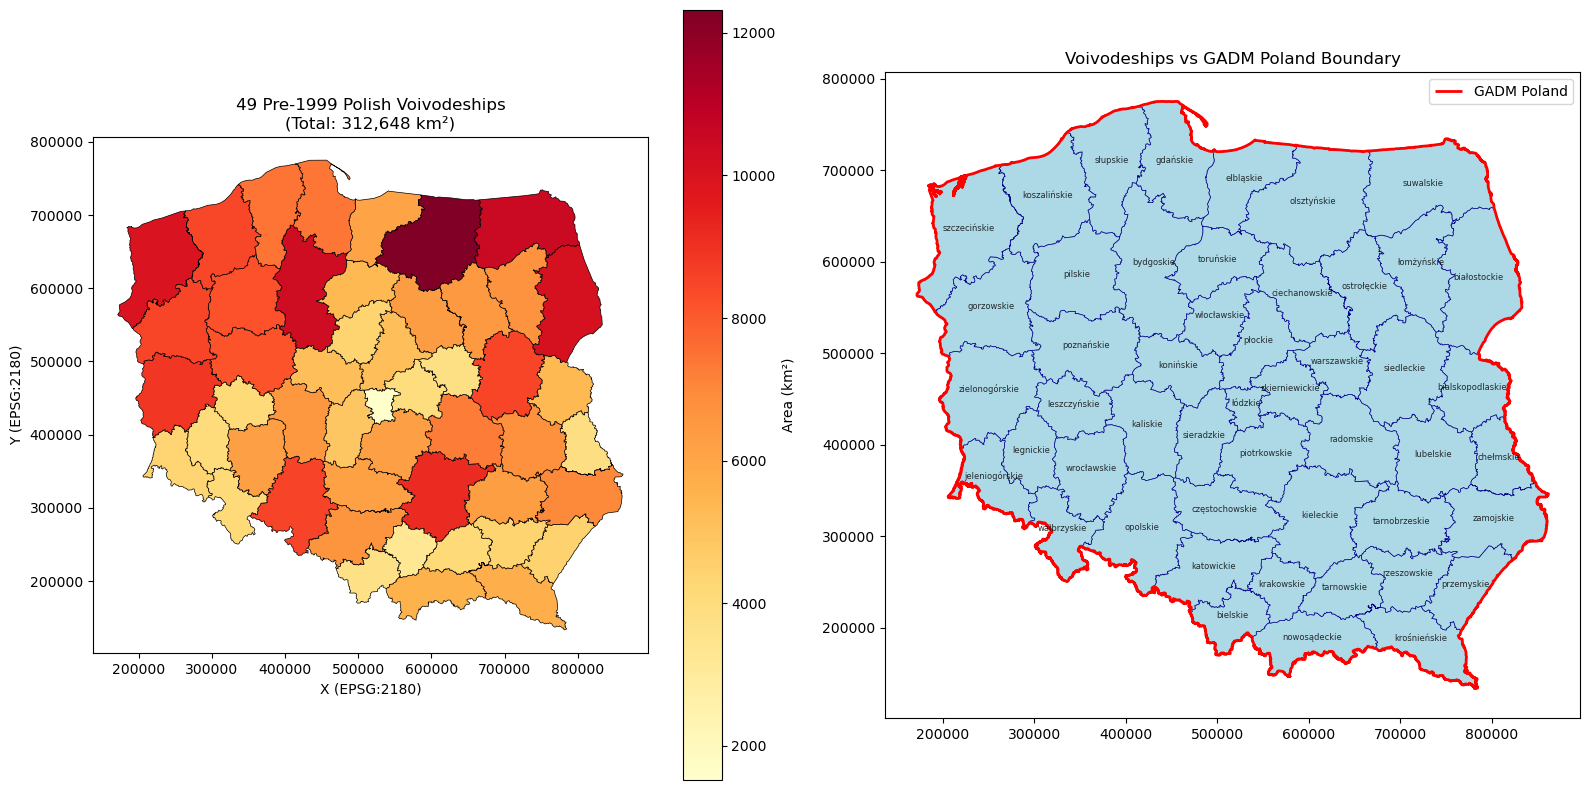

✓ Exported EPSG:2180: voivodeships_1975_49_clean_EPSG2180.geojson
✓ Exported WGS84: voivodeships_1975_49_clean.geojson

FINAL EXTRACTION SUMMARY
Source: new_map.svg
Voivodeships: 49
Columns: ['voiv_id', 'name', 'area_km2', 'geometry']
Total area: 312,648 km²
Area accuracy: 100.14% of GADM
Output files:
  - voivodeships_1975_49_clean.geojson
  - voivodeships_1975_49_clean_EPSG2180.geojson


In [22]:
# Cell 21: Visualize and export the final 49 voivodeships

# Reload GADM for overlay (shapefile format)
gadm_path = geo_root / 'gadm41_POL_shp' / 'gadm41_POL_0.shp'
poland_2180 = gpd.read_file(gadm_path).to_crs(epsg=2180)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: colored by area with names
voiv_filtered.plot(ax=axes[0], column='area_km2', cmap='YlOrRd', edgecolor='black', 
                   linewidth=0.5, legend=True, legend_kwds={'label': 'Area (km²)'})
axes[0].set_title(f'49 Pre-1999 Polish Voivodeships\n(Total: {voiv_filtered["area_km2"].sum():,.0f} km²)')
axes[0].set_xlabel('X (EPSG:2180)')
axes[0].set_ylabel('Y (EPSG:2180)')

# Right: overlay with GADM
voiv_filtered.plot(ax=axes[1], facecolor='lightblue', edgecolor='darkblue', linewidth=0.5)

poland_2180.boundary.plot(ax=axes[1], color='red', linewidth=2, label='GADM Poland')
axes[1].set_title('Voivodeships vs GADM Poland Boundary')
axes[1].legend()

# Plot labels of the geometries
for idx, row in voiv_filtered.iterrows():
    centroid = row.geometry.centroid
    axes[1].annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=6, alpha=0.8)


plt.tight_layout()
plt.show()

# Export final cleaned files
output_wgs84 = geo_root / 'voivodeships_1975_49_clean.geojson'
output_2180 = geo_root / 'voivodeships_1975_49_clean_EPSG2180.geojson'

# Export EPSG:2180
voiv_filtered.to_file(output_2180, driver='GeoJSON')
print(f"✓ Exported EPSG:2180: {output_2180.name}")

# Export WGS84
voiv_wgs84 = voiv_filtered.to_crs(epsg=4326)
voiv_wgs84.to_file(output_wgs84, driver='GeoJSON')
print(f"✓ Exported WGS84: {output_wgs84.name}")

print(f"\n{'='*60}")
print("FINAL EXTRACTION SUMMARY")
print('='*60)
print(f"Source: new_map.svg")
print(f"Voivodeships: {len(voiv_filtered)}")
print(f"Columns: {list(voiv_filtered.columns)}")
print(f"Total area: {voiv_filtered['area_km2'].sum():,.0f} km²")
print(f"Area accuracy: {voiv_filtered['area_km2'].sum()/312196*100:.2f}% of GADM")
print(f"Output files:")
print(f"  - {output_wgs84.name}")
print(f"  - {output_2180.name}")
print('='*60)